In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, precision_score

In [3]:
df = pd.read_csv("data/student_exam_performance_dataset.csv")

# Data preprocessing

#### Removing unnecesary columns

In [ ]:
# unnecessary column removed
# columns that explicitly show that student failed or passed final exam removed

df.drop(columns = ['student_id','grade_category','final_exam_score'], inplace=True)

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   gender                      10000 non-null  str    
 1   age                         10000 non-null  int64  
 2   parental_education          10000 non-null  str    
 3   family_income               10000 non-null  str    
 4   internet_access             10000 non-null  str    
 5   study_environment           10000 non-null  str    
 6   study_hours_per_day         10000 non-null  float64
 7   attendance_rate             10000 non-null  float64
 8   sleep_hours                 10000 non-null  float64
 9   social_media_hours          10000 non-null  float64
 10  assignment_completion_rate  10000 non-null  float64
 11  participation_score         10000 non-null  float64
 12  online_courses_completed    10000 non-null  int64  
 13  tutoring                    10000 non-null 

In [5]:
df.head()

,student_id,gender,age,parental_education,family_income,internet_access,study_environment,study_hours_per_day,attendance_rate,sleep_hours,...,online_courses_completed,tutoring,math_score,reading_score,writing_score,science_score,final_exam_score,previous_gpa,pass_fail,grade_category
0,S00001,Male,17,High School,Medium,Yes,Quiet,2.98,96.5,6.05,...,1,Yes,42.8,62.4,54.8,51.8,49.1,2.44,Fail,F
1,S00002,Female,18,High School,Low,Yes,Quiet,4.45,95.7,6.96,...,0,Yes,77.9,73.5,64.4,61.6,70.1,2.79,Pass,C
2,S00003,Male,17,High School,Medium,No,Quiet,3.75,76.0,7.02,...,4,Yes,53.5,38.3,36.3,47.1,42.2,1.49,Fail,F
3,S00004,Male,18,Bachelor,Medium,Yes,Quiet,2.03,72.6,6.23,...,4,No,28.3,23.5,32.0,39.0,31.9,1.34,Fail,F
4,S00005,Male,18,Bachelor,Medium,Yes,Quiet,5.14,87.3,8.54,...,0,No,74.7,54.9,73.6,55.5,66.4,2.60,Pass,C


#### Filling missing values

In [ ]:
#example of filling null values in columns, but because there are no null values in any column in this dataset, code is put under comment

#df['study_hours_per_day'] = df['study_hours_per_day'].fillna(df['study_hours_per_day'].mean())
#df['parental_education'] = df['parental_education'].fillna(df['parental_education'].mode()[0])

#### Encoding categorical columns

In [ ]:


categorical_col = df.select_dtypes("string").columns
categorical_col

Index(['gender', 'parental_education', 'family_income', 'internet_access',
       'study_environment', 'tutoring', 'pass_fail'],
      dtype='str')

In [11]:
df_categoric = df[categorical_col]

In [35]:
df_categoric.head(10)

,gender,parental_education,family_income,internet_access,study_environment,tutoring,pass_fail
0,1,0,1,1,0,1,Fail
1,0,0,0,1,0,1,Pass
2,1,0,1,0,0,1,Fail
3,1,1,1,1,0,0,Fail
4,1,1,1,1,0,0,Pass
5,0,2,1,1,0,0,Fail
6,1,0,2,1,0,0,Fail
7,1,1,0,1,1,0,Pass
8,1,2,1,1,1,0,Fail
9,0,2,0,1,0,1,Pass


In [13]:
encoder = LabelEncoder()

In [19]:
df['gender'].unique()

array([1, 0])

In [ ]:
df_categoric['gender'] = encoder.fit_transform(df_categoric['gender'])
df['gender'] = encoder.fit_transform(df['gender'])

In [22]:
df['parental_education'].unique()

array([0, 1, 2, 3])

In [21]:
df_categoric['parental_education'] = df_categoric['parental_education'].map({'High School':0, 'Bachelor':1,'Master':2,'PhD':3 })
df['parental_education'] = df['parental_education'].map({'High School':0, 'Bachelor':1,'Master':2,'PhD':3 })

In [25]:
df['family_income'].unique()

array([1, 0, 2])

In [24]:
df_categoric['family_income'] = df_categoric['family_income'].map({'Low':0, 'Medium':1,'High':2 })
df['family_income'] = df['family_income'].map({'Low':0, 'Medium':1,'High':2 })

In [28]:
df['internet_access'].unique()

array([1, 0])

In [27]:
df_categoric['internet_access'] = df_categoric['internet_access'].map({'No':0, 'Yes':1 })
df['internet_access'] = df['internet_access'].map({'No':0, 'Yes':1 })

In [31]:
df['study_environment'].unique()

array([0, 1, 2])

In [30]:
df_categoric['study_environment'] = df_categoric['study_environment'].map({'Quiet':0, 'Moderate':1,'Noisy':2 })
df['study_environment'] = df['study_environment'].map({'Quiet':0, 'Moderate':1,'Noisy':2 })

In [34]:
df['tutoring'].unique()

array([1, 0])

In [33]:
df_categoric['tutoring'] = df_categoric['tutoring'].map({'No':0, 'Yes':1 })
df['tutoring'] = df['tutoring'].map({'No':0, 'Yes':1 })

In [38]:
df['pass_fail'].unique()

array([0, 1])

In [37]:
df_categoric['pass_fail'] = df_categoric['pass_fail'].map({'Fail':0, 'Pass':1 })
df['pass_fail'] = df['pass_fail'].map({'Fail':0, 'Pass':1 })

In [39]:
df.head()

,gender,age,parental_education,family_income,internet_access,study_environment,study_hours_per_day,attendance_rate,sleep_hours,social_media_hours,assignment_completion_rate,participation_score,online_courses_completed,tutoring,math_score,reading_score,writing_score,science_score,previous_gpa,pass_fail
0,1,17,0,1,1,0,2.98,96.5,6.05,0.1,80.5,68.7,1,1,42.8,62.4,54.8,51.8,2.44,0
1,0,18,0,0,1,0,4.45,95.7,6.96,2.9,70.9,92.6,0,1,77.9,73.5,64.4,61.6,2.79,1
2,1,17,0,1,0,0,3.75,76.0,7.02,2.4,77.6,45.8,4,1,53.5,38.3,36.3,47.1,1.49,0
3,1,18,1,1,1,0,2.03,72.6,6.23,3.5,63.5,72.9,4,0,28.3,23.5,32.0,39.0,1.34,0
4,1,18,1,1,1,0,5.14,87.3,8.54,2.1,71.8,55.7,0,0,74.7,54.9,73.6,55.5,2.60,1


#### Train and test split

In [40]:
x = df.drop(columns=['pass_fail'])
y = df['pass_fail']

In [43]:
y.info()

<class 'pandas.Series'>
RangeIndex: 10000 entries, 0 to 9999
Series name: pass_fail
Non-Null Count  Dtype
--------------  -----
10000 non-null  int64
dtypes: int64(1)
memory usage: 78.3 KB


In [44]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 0)

In [49]:
y_test.value_counts()

pass_fail
0    1031
1     969
Name: count, dtype: int64

#### Data scaling

In [50]:
scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [51]:
x_train

array([[-0.99975003, -0.43567851, -1.02230004, ...,  1.40651757,
         0.12148791,  0.92977741],
       [ 1.00025003, -0.43567851,  0.09512042, ...,  1.72711283,
         2.43928563,  1.27937745],
       [ 1.00025003,  0.45710533,  1.21254088, ..., -0.71835798,
        -1.3416219 , -1.27822285],
       ...,
       [-0.99975003, -1.32846235,  0.09512042, ..., -1.1657002 ,
        -1.68929156, -1.46222287],
       [ 1.00025003, -1.32846235, -1.02230004, ..., -0.18154732,
        -0.50866334, -1.07582282],
       [-0.99975003,  0.45710533,  0.09512042, ...,  0.52674453,
        -0.03061756,  0.30417734]], shape=(8000, 19))

### Training

In [52]:
model = LogisticRegression(max_iter=1000)
model.fit(x_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

### Evaluation

In [53]:
y_pred = model.predict(x_test)
y_pred

array([0, 1, 1, ..., 1, 0, 0], shape=(2000,))

[[978  53]
 [ 51 918]]
              precision    recall  f1-score   support

           0       0.95      0.95      0.95      1031
           1       0.95      0.95      0.95       969

    accuracy                           0.95      2000
   macro avg       0.95      0.95      0.95      2000
weighted avg       0.95      0.95      0.95      2000



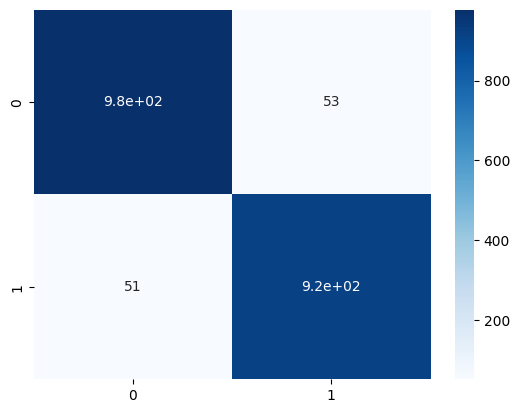

In [54]:
matrix1 = confusion_matrix(y_test,y_pred)
print(matrix1)
ax1 = sns.heatmap(matrix1, annot=True, cmap='Blues')
print(classification_report(y_test,y_pred))